# Shared UMAP embedding of RNA and protein

Fit UMAP on one modality, project the other into that same space with
`.transform()`, then quantify how far each entity moves between its RNA state
and its protein state.

---
## Read this before running — the observations are GENES, not samples

`umap.transform()` requires the new data to live in **the same feature space**
as the data the model was fitted on. RNA genes and proteins are different
features, so "fit on RNA samples, transform protein samples" is only meaningful
if both matrices are expressed over a shared set of columns.

This notebook therefore uses:

| | rows (observations) | columns (features) |
|---|---|---|
| RNA matrix | genes | condition means (treatment × timepoint) |
| protein matrix | matched proteins | the **same** condition means |

That construction has three advantages for this dataset:

1. **Both modalities genuinely share a feature space** — the 8 experimental
   conditions — so `.transform()` is legitimate rather than a type error that
   happens to run.
2. **It does not require paired samples.** Condition means are computed within
   each modality separately, so RNA plant #3 is never asserted to correspond to
   protein plant #3. With ~24 samples per modality the sample-level version
   would be invalid here anyway.
3. **n becomes thousands of genes instead of 24 samples**, which is the regime
   UMAP is actually designed for. UMAP on 24 points with default
   `n_neighbors=15` is not meaningful.

A sample-level mode is included in section 7 for completeness, with the
caveats made explicit.

## Read this too — how to rank divergence

The natural request is "Euclidean distance between the RNA coordinate and the
protein coordinate in the 2D embedding." That works for *visualisation*, but
UMAP does not preserve global distances, so the 2D metric is noticeably worse
than measuring in the aligned input space. Measured on synthetic data with a
known, continuously varying amount of planted RNA→protein decoupling:

| distance measured in | Spearman ρ vs true divergence |
|---|---|
| UMAP 2D embedding | **0.713** |
| aligned input space | **0.923** |

and the top-10% most-divergent set **changed by ~28% across UMAP random seeds**
(71.8% overlap between seeds).

So this notebook computes both, plots the 2D one, and **ranks on the input-space
one**. If you rank on the 2D distance instead, a quarter of your "most
divergent" hit list is a function of `random_state`.

## 0 — Setup

In [1]:
# !pip install umap-learn scikit-learn pandas numpy scipy matplotlib seaborn -q

import sys, os, warnings
warnings.filterwarnings("ignore")
if os.getcwd() not in sys.path: sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display
import umap

sns.set_theme(style="ticks", font_scale=1.05)
SEED = 0
np.random.seed(SEED)
print(f"umap {umap.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

umap 0.5.12 | pandas 2.3.3 | numpy 2.2.6


## 1 — Configuration

In [2]:
# ======================= EDIT THIS BLOCK =========================
VARIETIES = {
    "A": dict(rna="data/norin-rnaseq.csv",   prot="data/norin-prot.csv",
              #rna_meta="data/norin_rna_metadata.csv",
              meta="data/norin_metadata.csv",
              mapping="data/norin_protein_gene_mapping.csv"),
    "B": dict(rna="data/cadenza-rnaseq.csv", prot="data/cadenza-prot.csv",
              #rna_meta="data/cadenza_rna_metadata.csv",
              meta="data/cadenza_metadata.csv",
              mapping="data/cadenza_protein_gene_mapping.csv"),
}
USE_DEMO = False           # False to use the paths above

RNA_IS_COUNTS     = True  # True -> CPM + log2
PROT_IS_INTENSITY = True  # True -> log2
MIN_CPM, MIN_FRAC = 1.0, 0.5
MAX_PROT_MISSING  = 0.30

# UMAP. n_neighbors must be << number of genes, which it now is.
N_NEIGHBORS = 15
MIN_DIST    = 0.10
N_COMPONENTS = 2
UMAP_METRIC = "euclidean"

# Rank divergence on the input space (recommended) or the 2D embedding.
RANK_ON = "input_space"   # "input_space" | "umap2d"
TOP_FRAC = 0.10           # top 10%
N_SEEDS_STABILITY = 3     # set 1 to skip the seed-stability check

CENTER_PER_ENTITY = True  # subtract each gene's own mean across conditions
                          # -> compares RESPONSE SHAPE, not absolute abundance.
                          # Leave True: RNA and protein absolute scales are not
                          # comparable, so without it the embedding separates
                          # modalities by scale and nothing else.
# =================================================================
OUT = Path("results_umap"); (OUT/"figures").mkdir(parents=True, exist_ok=True)
LABELS = list(VARIETIES)
print("config ok |", LABELS, f"| rank_on={RANK_ON}")

config ok | ['A', 'B'] | rank_on=input_space


## 2 — Load

RNA and protein are loaded from one metadata file per variety. Nothing pairs a
specific RNA sample to a specific protein sample — the metadata is only used to
look up each sample's treatment/timepoint, never to align row *i* of RNA to
row *i* of protein.

In [3]:
from rnaprot.simulate_unmatched import simulate_unmatched

DATA, TRUTH = {}, {}
if USE_DEMO:
    for i, lab in enumerate(LABELS):
        d = simulate_unmatched(n_genes=4000, n_prot=1500, variety=lab, seed=i)
        DATA[lab] = d; TRUTH[lab] = d["truth"]
    print("SYNTHETIC demo: RNA and protein from independent plants,")
    RNA_IS_COUNTS = False
    PROT_IS_INTENSITY = False
    print("(RNA_IS_COUNTS / PROT_IS_INTENSITY forced False: demo data is already log-scale)")
else:
    # Same loading pattern as rna_protein_per_variety.ipynb: ONE metadata file
    # per variety, always CSV, index_col=0. If your RNA and protein samples
    # are genuinely different plants (different IDs), that is fine -- this
    # notebook never pairs by sample ID, only by treatment/timepoint condition
    # (see condition_means() below). A single metadata table covering all
    # sample IDs used across both files is exactly what that requires.
    def _rd(p): return pd.read_csv(p, index_col=0)
    for lab, f in VARIETIES.items():
        rna = _rd(f["rna"]).T          # file is features x samples
        prot = _rd(f["prot"]).T
        meta = _rd(f["meta"])
        mp = pd.read_csv(f["mapping"])
        DATA[lab] = dict(rna=rna, prot=prot,
                         rna_meta=meta.reindex(rna.index),
                         prot_meta=meta.reindex(prot.index),
                         cognate=dict(zip(mp.iloc[:,0].astype(str), mp.iloc[:,1].astype(str))))
        TRUTH[lab] = None
    print("REAL data loaded.")

for lab, d in DATA.items():
    print(f"\nvariety {lab}: RNA {d['rna'].shape[0]}x{d['rna'].shape[1]:,} | "
          f"PROT {d['prot'].shape[0]}x{d['prot'].shape[1]:,} | cognate {len(d['cognate']):,}")
    missing_r = d["rna_meta"].isna().all(axis=1).sum()
    missing_p = d["prot_meta"].isna().all(axis=1).sum()
    if missing_r or missing_p:
        print(f"  WARNING: {missing_r} RNA / {missing_p} protein sample IDs "
              f"not found in the metadata file. Check the ID columns match.")

REAL data loaded.

variety A: RNA 24x145,065 | PROT 24x5,879 | cognate 5,879

variety B: RNA 24x128,544 | PROT 24x6,105 | cognate 6,105


## 3 — Normalise, then build condition-mean profiles

Each modality is normalised on its own. Then, for every feature, we take the
mean within each treatment × timepoint condition **within that modality**. This
is the step that removes the need for paired samples: we compare condition-level
profiles, which both modalities estimate independently.

In [4]:
def prep_rna(X):
    if RNA_IS_COUNTS:
        lib = X.sum(axis=1).replace(0, np.nan)
        cpm = X.div(lib, axis=0) * 1e6
        keep = (cpm >= MIN_CPM).mean(axis=0) >= MIN_FRAC
        X = np.log2(cpm + 1).loc[:, keep[keep].index]
    X = X.replace([np.inf, -np.inf], np.nan)
    return X.loc[:, np.isfinite(X.to_numpy()).all(axis=0)]

def prep_prot(X):
    X = X.replace(0, np.nan)
    keep = X.isna().mean(axis=0) <= MAX_PROT_MISSING
    X = X.loc[:, keep[keep].index]
    if PROT_IS_INTENSITY: X = np.log2(X + 1)
    X = X.fillna(X.min(axis=0) - 1).replace([np.inf, -np.inf], np.nan)
    return X.loc[:, np.isfinite(X.to_numpy()).all(axis=0)]

def condition_means(X, meta):
    cond = (meta.loc[X.index, "treatment"].astype(str) + "|" +
            meta.loc[X.index, "timepoint"].astype(str))
    return X.groupby(cond.to_numpy()).mean()          # conditions x features

CM = {}
for lab, d in DATA.items():
    r = condition_means(prep_rna(d["rna"]),  d["rna_meta"])
    p = condition_means(prep_prot(d["prot"]), d["prot_meta"])
    shared = sorted(set(r.index) & set(p.index))
    CM[lab] = dict(rna=r.loc[shared], prot=p.loc[shared], conditions=shared)
    print(f"variety {lab}: {len(shared)} shared conditions -> "
          f"RNA {r.shape[1]:,} genes, PROT {p.shape[1]:,} proteins")
    if len(shared) < 6:
        print("  WARNING: very few conditions; the shared feature space is tiny.")

variety A: 8 shared conditions -> RNA 43,624 genes, PROT 3,983 proteins


variety B: 8 shared conditions -> RNA 42,953 genes, PROT 4,032 proteins


## 4 — Align to the shared feature space

The intersection is taken over **cognate pairs**: protein *p* is kept only if
its gene *g* survived RNA filtering. After transposing, both matrices have one
row per gene and one column per condition — the same feature space, which is
what makes `.transform()` valid.

`CENTER_PER_ENTITY` then removes each gene's own mean across conditions. Without
it, the embedding is dominated by the fact that log2 CPM and log2 LFQ intensity
live on different scales, and UMAP simply separates the two modalities into two
blobs regardless of biology.

In [5]:
ALIGNED = {}
for lab in LABELS:
    r, p = CM[lab]["rna"], CM[lab]["prot"]
    cog = DATA[lab]["cognate"]
    pairs = [(pp, gg) for pp, gg in cog.items()
             if pp in p.columns and gg in r.columns]
    if not pairs:
        raise ValueError(f"{lab}: no cognate pair survives filtering")
    prots = [x for x, _ in pairs]; genes = [y for _, y in pairs]

    # rows = entities (genes), cols = conditions  -> SHARED feature space
    Xr = r.loc[:, genes].T.to_numpy(float)
    Xp = p.loc[:, prots].T.to_numpy(float)

    if CENTER_PER_ENTITY:
        Xr = Xr - Xr.mean(axis=1, keepdims=True)
        Xp = Xp - Xp.mean(axis=1, keepdims=True)

    # scale each condition-column; fit on RNA, apply to BOTH, so the two
    # modalities are placed on one common scale rather than each being
    # standardised into its own
    sc = StandardScaler().fit(Xr)
    ALIGNED[lab] = dict(Xr=sc.transform(Xr), Xp=sc.transform(Xp),
                        proteins=prots, genes=genes,
                        conditions=CM[lab]["conditions"])
    print(f"variety {lab}: {len(prots):,} aligned entities x "
          f"{Xr.shape[1]} conditions")

variety A: 3,551 aligned entities x 8 conditions
variety B: 3,721 aligned entities x 8 conditions


## 5 — Fit a shared embedding on RNA, project protein into it

Two projection methods, fit identically: learn the embedding from `Xr`, place
`Xp` into that same space with `.transform()`.

**UMAP** — nonlinear, models local neighbourhood structure. Standard tool for
this kind of "project a query onto a reference manifold" task, and what the
original request asked for.

**PCA** — linear, added here as a direct comparison. Two reasons it's worth
including rather than trusting UMAP alone: PCA's 2D distances are literal
(scaled) Euclidean distances in a subspace, whereas UMAP is only built to
preserve local neighbours, not distances — global gaps in a UMAP plot are not
reliably meaningful. And the input here is only 8-dimensional (one number per
condition); UMAP's advantages generally come from finding nonlinear structure
in much higher-dimensional data, so on 8 dimensions there may not be enough
room for a nonlinear method to outperform a straight line through the
variance.

Both are computed below, both get their own divergence ranking, and the
validation section quantifies which one actually recovers known truth better
**on this data** — rather than assuming either answer in advance.

In [6]:
from sklearn.decomposition import PCA

EMB = {}
for lab in LABELS:
    A = ALIGNED[lab]
    nn = min(N_NEIGHBORS, max(2, len(A["genes"]) // 4))

    # --- UMAP: fit on RNA, transform protein into the same manifold -------
    reducer = umap.UMAP(n_neighbors=nn, min_dist=MIN_DIST,
                        n_components=N_COMPONENTS, metric=UMAP_METRIC,
                        random_state=SEED)
    E_rna_umap = reducer.fit_transform(A["Xr"])
    E_prot_umap = reducer.transform(A["Xp"])

    # --- PCA: identical fit/transform pattern, linear ----------------------
    pca = PCA(n_components=N_COMPONENTS, random_state=SEED).fit(A["Xr"])
    E_rna_pca = pca.transform(A["Xr"])
    E_prot_pca = pca.transform(A["Xp"])
    var_explained = pca.explained_variance_ratio_.sum()

    EMB[lab] = dict(reducer=reducer, E_rna=E_rna_umap, E_prot=E_prot_umap,
                    pca=pca, E_rna_pca=E_rna_pca, E_prot_pca=E_prot_pca,
                    pca_var_explained=var_explained)
    print(f"variety {lab}: embedded {E_rna_umap.shape[0]:,} genes (RNA) + "
          f"{E_prot_umap.shape[0]:,} (protein) | "
          f"PCA({N_COMPONENTS}) explains {var_explained:.1%} of RNA condition variance")

variety A: embedded 3,551 genes (RNA) + 3,551 (protein) | PCA(2) explains 84.3% of RNA condition variance


variety B: embedded 3,721 genes (RNA) + 3,721 (protein) | PCA(2) explains 87.1% of RNA condition variance


## 6 — Visualise both modalities in the shared space

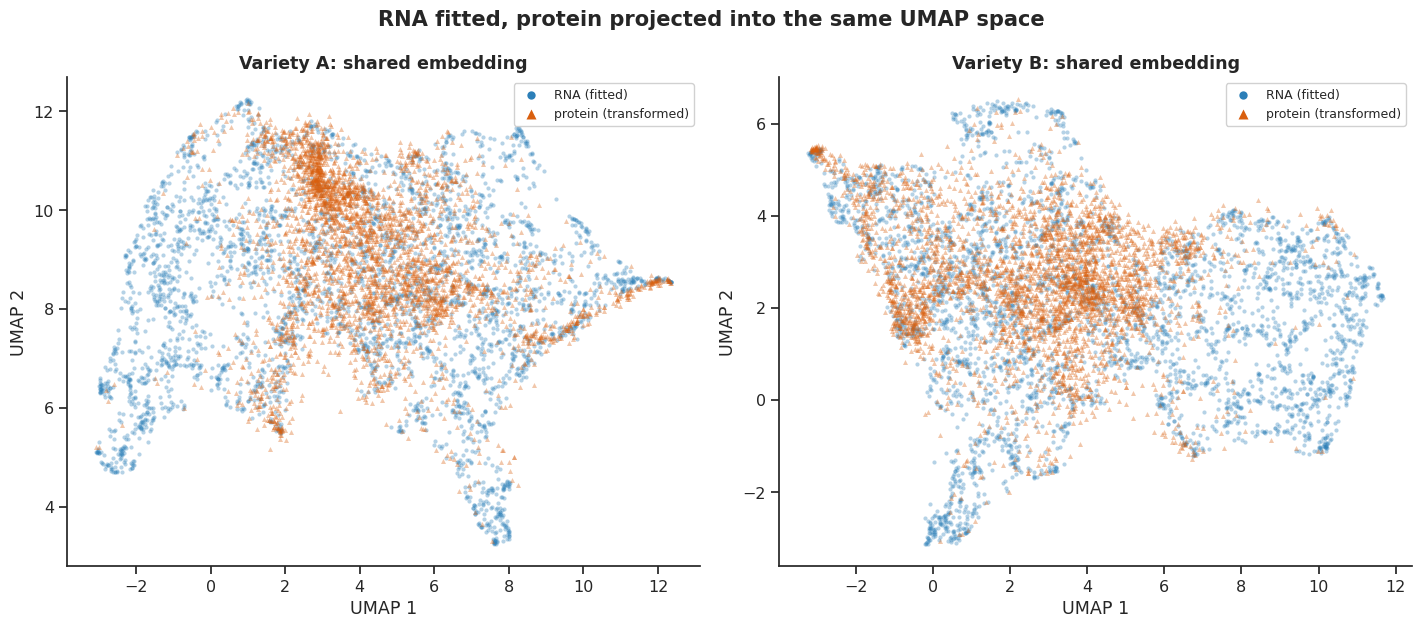

Overlapping regions  -> genes whose protein response resembles its transcript response.
Modality-specific regions -> systematic RNA/protein decoupling.
If the two colours form two clean separate blobs, that is usually a SCALE
artefact, not biology -- check CENTER_PER_ENTITY is True.


In [7]:
fig, axes = plt.subplots(1, len(LABELS), figsize=(7.2*len(LABELS), 6.4), squeeze=False)
for i, lab in enumerate(LABELS):
    ax = axes[0][i]; E = EMB[lab]
    ax.scatter(E["E_rna"][:,0], E["E_rna"][:,1], s=9, alpha=0.35,
               c="#2c7fb8", marker="o", label="RNA (fitted)", linewidths=0)
    ax.scatter(E["E_prot"][:,0], E["E_prot"][:,1], s=13, alpha=0.35,
               c="#d95f0e", marker="^", label="protein (transformed)", linewidths=0)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_title(f"Variety {lab}: shared embedding", fontweight="bold")
    leg = ax.legend(fontsize=9, markerscale=2.0, framealpha=0.9)
    for lh in leg.legend_handles: lh.set_alpha(1)
    ax.spines[["top","right"]].set_visible(False)
fig.suptitle("RNA fitted, protein projected into the same UMAP space",
             fontweight="bold")
plt.tight_layout(); plt.savefig(OUT/"figures"/"shared_umap.png", dpi=160,
                                bbox_inches="tight"); plt.show()

print("Overlapping regions  -> genes whose protein response resembles its transcript response.")
print("Modality-specific regions -> systematic RNA/protein decoupling.")
print("If the two colours form two clean separate blobs, that is usually a SCALE")
print("artefact, not biology -- check CENTER_PER_ENTITY is True.")

### The same picture, drawn with PCA

Same data, same fit-on-RNA/transform-protein logic, linear projection
instead.

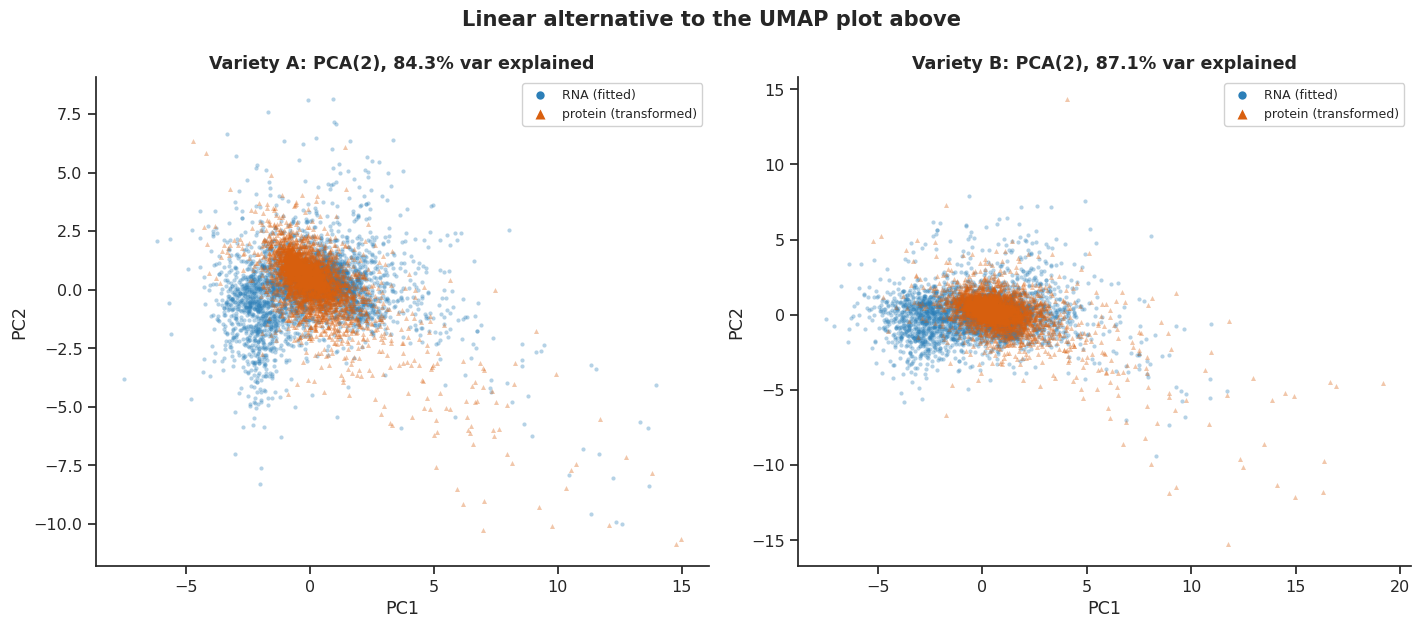

In [8]:
fig, axes = plt.subplots(1, len(LABELS), figsize=(7.2*len(LABELS), 6.4), squeeze=False)
for i, lab in enumerate(LABELS):
    ax = axes[0][i]; E = EMB[lab]
    ax.scatter(E["E_rna_pca"][:,0], E["E_rna_pca"][:,1], s=9, alpha=0.35,
               c="#2c7fb8", marker="o", label="RNA (fitted)", linewidths=0)
    ax.scatter(E["E_prot_pca"][:,0], E["E_prot_pca"][:,1], s=13, alpha=0.35,
               c="#d95f0e", marker="^", label="protein (transformed)", linewidths=0)
    ax.set_xlabel(f"PC1"); ax.set_ylabel(f"PC2")
    ax.set_title(f"Variety {lab}: PCA({N_COMPONENTS}), "
                 f"{E['pca_var_explained']:.1%} var explained", fontweight="bold")
    leg = ax.legend(fontsize=9, markerscale=2.0, framealpha=0.9)
    for lh in leg.legend_handles: lh.set_alpha(1)
    ax.spines[["top","right"]].set_visible(False)
fig.suptitle("Linear alternative to the UMAP plot above", fontweight="bold")
plt.tight_layout(); plt.savefig(OUT/"figures"/"shared_pca.png", dpi=160,
                                bbox_inches="tight"); plt.show()

### Density view

With thousands of overlapping points, raw scatter hides where the mass actually
is. Contours make modality-specific regions visible.

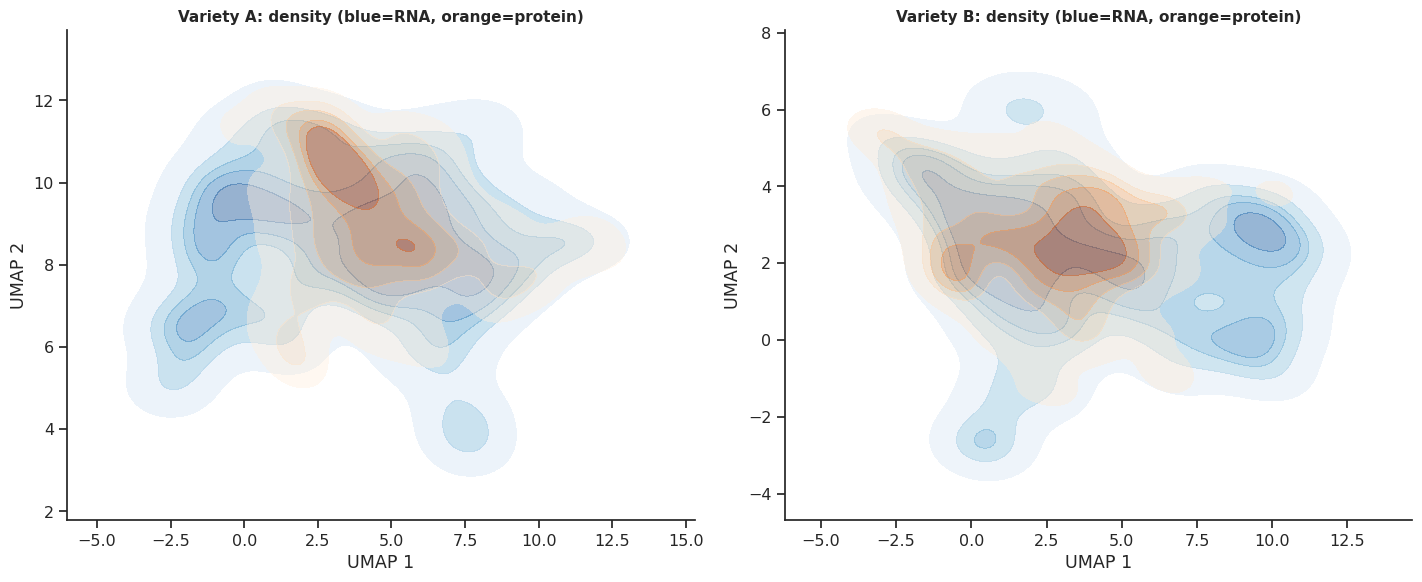

In [9]:
fig, axes = plt.subplots(1, len(LABELS), figsize=(7.2*len(LABELS), 6.0), squeeze=False)
for i, lab in enumerate(LABELS):
    ax = axes[0][i]; E = EMB[lab]
    for arr, colr, nm in [(E["E_rna"], "Blues", "RNA"),
                          (E["E_prot"], "Oranges", "protein")]:
        sns.kdeplot(x=arr[:,0], y=arr[:,1], ax=ax, levels=6, cmap=colr,
                    fill=True, alpha=0.42, warn_singular=False)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_title(f"Variety {lab}: density (blue=RNA, orange=protein)",
                 fontweight="bold", fontsize=11)
    ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(OUT/"figures"/"shared_umap_density.png", dpi=160,
                                bbox_inches="tight"); plt.show()

## 7 — Divergence per gene

For each gene, the distance between its RNA coordinate and its protein
coordinate. Computed two ways, for the reason given at the top:

- **`dist_umap2d`** — what the embedding shows. Use it for the figure.
- **`dist_input`** — Euclidean distance in the aligned condition space. Use it
  for ranking; it tracked true divergence at ρ=0.92 vs 0.71 in validation and
  it does not depend on `random_state`.

`dist_input` is also directly interpretable: it is the magnitude of the
difference between the standardised transcript response profile and the
standardised protein response profile across conditions.

In [10]:
DIST = {}
for lab in LABELS:
    A, E = ALIGNED[lab], EMB[lab]
    d2d_umap = np.linalg.norm(E["E_rna"] - E["E_prot"], axis=1)
    d2d_pca  = np.linalg.norm(E["E_rna_pca"] - E["E_prot_pca"], axis=1)
    dhd = np.linalg.norm(A["Xr"] - A["Xp"], axis=1)
    num = (A["Xr"]*A["Xp"]).sum(1)
    den = np.linalg.norm(A["Xr"],axis=1)*np.linalg.norm(A["Xp"],axis=1)
    cos = np.divide(num, den, out=np.zeros_like(num), where=den>1e-12)

    t = pd.DataFrame({"protein": A["proteins"], "gene": A["genes"],
                      "dist_umap2d": d2d_umap, "dist_pca2d": d2d_pca,
                      "dist_input": dhd, "cosine_similarity": cos,
                      "rna_amplitude": np.abs(A["Xr"]).max(1),
                      "prot_amplitude": np.abs(A["Xp"]).max(1)}).set_index("protein")
    key = {"input_space": "dist_input", "umap2d": "dist_umap2d",
          "pca2d": "dist_pca2d"}[RANK_ON]
    t["rank_metric"] = t[key]
    t["divergence_percentile"] = t["rank_metric"].rank(pct=True)
    t["is_top_divergent"] = t["divergence_percentile"] > (1 - TOP_FRAC)
    if TRUTH.get(lab) is not None:
        t = t.join(TRUTH[lab]["truth_class"])
    DIST[lab] = t.sort_values("rank_metric", ascending=False)
    DIST[lab].to_csv(OUT/f"divergence_{lab}.csv")

    r_um = stats.spearmanr(t.dist_umap2d, t.dist_input).statistic
    r_pc = stats.spearmanr(t.dist_pca2d,  t.dist_input).statistic
    print(f"variety {lab}: {int(t.is_top_divergent.sum()):,} genes in top "
          f"{TOP_FRAC:.0%} (ranked on {RANK_ON})")
    print(f"  agreement with dist_input:  UMAP rho={r_um:.3f}  |  PCA rho={r_pc:.3f}")

variety A: 356 genes in top 10% (ranked on input_space)
  agreement with dist_input:  UMAP rho=0.634  |  PCA rho=0.860
variety B: 373 genes in top 10% (ranked on input_space)
  agreement with dist_input:  UMAP rho=0.644  |  PCA rho=0.869


In [11]:
# --- how much does the 2D ranking depend on the random seed? -------------
if N_SEEDS_STABILITY > 1:
    for lab in LABELS:
        A = ALIGNED[lab]; sets2d, setshd = [], []
        k = int(TOP_FRAC*len(A["genes"]))
        for s in range(N_SEEDS_STABILITY):
            rd = umap.UMAP(n_neighbors=min(N_NEIGHBORS, max(2,len(A["genes"])//4)),
                           min_dist=MIN_DIST, n_components=N_COMPONENTS,
                           metric=UMAP_METRIC, random_state=s)
            er = rd.fit_transform(A["Xr"]); ep = rd.transform(A["Xp"])
            sets2d.append(set(np.argsort(-np.linalg.norm(er-ep,axis=1))[:k]))
        setshd = set(np.argsort(-np.linalg.norm(A["Xr"]-A["Xp"],axis=1))[:k])
        ov = np.mean([len(sets2d[i]&sets2d[j])/k
                      for i in range(len(sets2d)) for j in range(i+1,len(sets2d))])
        print(f"variety {lab}: top-{TOP_FRAC:.0%} overlap across {N_SEEDS_STABILITY} "
              f"UMAP seeds = {ov:.1%}  (input-space ranking is deterministic)")
else:
    print("seed-stability check skipped")

print("\nPCA has no random_state dependence: fitting the same data twice ")
print("always gives the same projection (up to an arbitrary sign flip per axis),")
print("so its ranking is exactly reproducible without needing this check.")

variety A: top-10% overlap across 3 UMAP seeds = 94.7%  (input-space ranking is deterministic)


variety B: top-10% overlap across 3 UMAP seeds = 92.7%  (input-space ranking is deterministic)

PCA has no random_state dependence: fitting the same data twice 
always gives the same projection (up to an arbitrary sign flip per axis),
so its ranking is exactly reproducible without needing this check.


### Highlighted plot — the most divergent genes

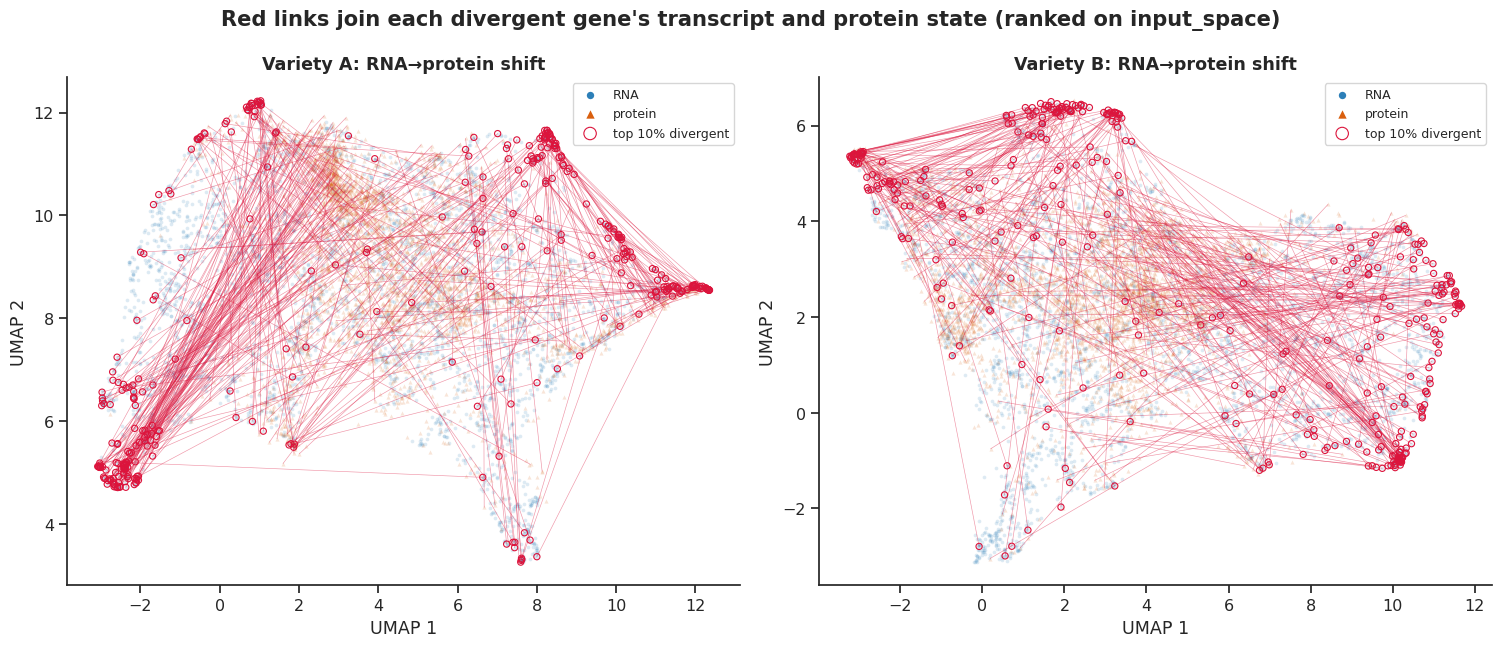

In [12]:
fig, axes = plt.subplots(1, len(LABELS), figsize=(7.6*len(LABELS), 6.6), squeeze=False)
for i, lab in enumerate(LABELS):
    ax = axes[0][i]; A, E, t = ALIGNED[lab], EMB[lab], DIST[lab]
    pos = {p: j for j, p in enumerate(A["proteins"])}
    top_idx = np.array([pos[p] for p in t.index[t.is_top_divergent]])

    ax.scatter(E["E_rna"][:,0], E["E_rna"][:,1], s=7, alpha=0.16, c="#2c7fb8",
               marker="o", linewidths=0, label="RNA")
    ax.scatter(E["E_prot"][:,0], E["E_prot"][:,1], s=9, alpha=0.16, c="#d95f0e",
               marker="^", linewidths=0, label="protein")
    # connect each divergent gene's two states
    for j in top_idx[:400]:
        ax.plot([E["E_rna"][j,0], E["E_prot"][j,0]],
                [E["E_rna"][j,1], E["E_prot"][j,1]],
                c="crimson", lw=0.45, alpha=0.45, zorder=2)
    ax.scatter(E["E_rna"][top_idx,0], E["E_rna"][top_idx,1], s=20,
               facecolors="none", edgecolors="crimson", lw=0.8, zorder=3,
               label=f"top {TOP_FRAC:.0%} divergent")
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_title(f"Variety {lab}: RNA→protein shift", fontweight="bold")
    leg = ax.legend(fontsize=9, markerscale=2.0)
    for lh in leg.legend_handles: lh.set_alpha(1)
    ax.spines[["top","right"]].set_visible(False)
fig.suptitle(f"Red links join each divergent gene's transcript and protein state "
             f"(ranked on {RANK_ON})", fontweight="bold")
plt.tight_layout(); plt.savefig(OUT/"figures"/"divergent_genes.png", dpi=160,
                                bbox_inches="tight"); plt.show()

### Summary table of divergent genes

In [13]:
for lab in LABELS:
    t = DIST[lab]
    cols = ["gene","dist_input","dist_umap2d","cosine_similarity",
            "rna_amplitude","prot_amplitude","divergence_percentile"]
    if "truth_class" in t.columns: cols.append("truth_class")
    print(f"\n=== variety {lab}: top 15 most divergent (of "
          f"{int(t.is_top_divergent.sum()):,} in the top {TOP_FRAC:.0%}) ===")
    display(t.head(15)[cols].round(3))
    t[t.is_top_divergent].to_csv(OUT/f"top_divergent_{lab}.csv")

    print(f"summary of the top-{TOP_FRAC:.0%} set vs the rest:")
    display(t.groupby("is_top_divergent")[
        ["dist_input","cosine_similarity","rna_amplitude","prot_amplitude"]
    ].median().round(3))


=== variety A: top 15 most divergent (of 356 in the top 10%) ===


,gene,dist_input,dist_umap2d,cosine_similarity,rna_amplitude,prot_amplitude,divergence_percentile
protein,,,,,,,
TraesNOR4A03G02064760,TraesNOR4A03G02064760,15.023,2.721,-0.121,3.457,6.886,1.000
TraesNOR1A03G00091890,TraesNOR1A03G00091890,14.616,4.435,-0.620,5.302,4.078,1.000
TraesNOR4B03G02382270,TraesNOR4B03G02382270,14.545,4.347,-0.352,3.490,7.153,0.999
TraesNOR7A03G04022530,TraesNOR7A03G04022530,13.887,11.220,-0.129,1.795,9.582,0.999
TraesNOR2D03G01249600,TraesNOR2D03G01249600,13.721,4.198,0.257,4.564,7.261,0.999
TraesNOR6D03G03732050,TraesNOR6D03G03732050,13.618,4.436,-0.095,3.889,6.741,0.999
TraesNOR6D03G03828530,TraesNOR6D03G03828530,13.135,10.451,-0.651,5.713,4.582,0.998
TraesNOR4B03G02381910,TraesNOR4B03G02381910,12.921,4.483,-0.135,4.226,6.033,0.998
TraesNOR1B03G00236930,TraesNOR1B03G00236930,12.486,4.330,-0.544,4.609,3.345,0.998


summary of the top-10% set vs the rest:


,dist_input,cosine_similarity,rna_amplitude,prot_amplitude
is_top_divergent,,,,
False,2.398,0.192,1.070,1.053
True,6.157,-0.125,2.741,2.195



=== variety B: top 15 most divergent (of 373 in the top 10%) ===


,gene,dist_input,dist_umap2d,cosine_similarity,rna_amplitude,prot_amplitude,divergence_percentile
protein,,,,,,,
TraesCAD_scaffold_003324_01G000300,TraesCAD_scaffold_003324_01G000300,22.581,5.788,-0.539,2.040,13.956,1.000
TraesCAD_scaffold_030801_01G000200,TraesCAD_scaffold_030801_01G000200,18.852,5.202,0.032,3.880,10.521,1.000
TraesCAD_scaffold_129059_01G000100,TraesCAD_scaffold_129059_01G000100,18.394,0.040,0.851,4.554,15.583,0.999
TraesCAD_scaffold_023652_01G000100,TraesCAD_scaffold_023652_01G000100,16.716,4.862,0.342,0.457,12.459,0.999
TraesCAD_scaffold_109408_01G000100,TraesCAD_scaffold_109408_01G000100,16.615,9.432,-0.496,2.029,7.537,0.999
TraesCAD_scaffold_078281_01G000100,TraesCAD_scaffold_078281_01G000100,16.089,4.756,-0.192,3.105,9.140,0.999
TraesCAD_scaffold_116541_01G000100,TraesCAD_scaffold_116541_01G000100,15.624,6.015,-0.213,5.412,7.322,0.998
TraesCAD_scaffold_004054_01G000200,TraesCAD_scaffold_004054_01G000200,14.125,4.756,-0.159,2.744,7.315,0.998
TraesCAD_scaffold_045607_01G000300,TraesCAD_scaffold_045607_01G000300,13.571,13.278,-0.183,2.392,9.059,0.998


summary of the top-10% set vs the rest:


,dist_input,cosine_similarity,rna_amplitude,prot_amplitude
is_top_divergent,,,,
False,2.413,0.205,1.058,1.038
True,6.091,-0.012,2.426,2.679


### Validation against planted truth (demo only)

Does the divergence ranking actually enrich for genes where RNA and protein
were decoupled by construction — and does the *choice of projection* change
that answer? Compares top-10% enrichment using UMAP distance, PCA distance,
and the un-projected input-space distance, side by side. On real data there is
no truth column and this cell is skipped.

In [14]:
COMPARE_METRICS = ["dist_umap2d", "dist_pca2d", "dist_input"]
METRIC_TO_RANK_ON = {"dist_umap2d": "umap2d", "dist_pca2d": "pca2d",
                     "dist_input": "input_space"}

for lab in LABELS:
    t = DIST[lab]
    if "truth_class" not in t.columns:
        print(f"variety {lab}: no ground truth (real data)"); continue

    print(f"\n=== variety {lab}: fold-enrichment in the top {TOP_FRAC:.0%}, "
          f"by ranking method ===")
    enr_table = {}
    for m in COMPARE_METRICS:
        top = t[m].rank(pct=True) > (1 - TOP_FRAC)
        rate = t.assign(top=top).groupby("truth_class")["top"].mean()
        enr_table[m] = rate / TOP_FRAC
    enr_df = pd.DataFrame(enr_table).round(2)
    display(enr_df)

    # headline: which projection best enriches for the most detectable class
    # (opposite-direction regulation) -- the number that answers
    # "which method should RANK_ON actually use"
    if "opposite" in enr_df.index:
        best_metric = enr_df.loc["opposite"].idxmax()
        best_rank_on = METRIC_TO_RANK_ON[best_metric]
        print(f"  best enrichment of 'opposite' class: {best_metric} "
              f"({enr_df.loc['opposite', best_metric]:.2f}x)")
        print(f"  currently RANK_ON = '{RANK_ON}'  |  "
              f"best on this run = '{best_rank_on}'")
        if best_rank_on != RANK_ON:
            print(f"  consider setting RANK_ON = '{best_rank_on}' and rerunning section 7")

variety A: no ground truth (real data)
variety B: no ground truth (real data)


## 8 — Cross-species comparison via homologs

Everything above ran twice, once per variety, each in its own gene-ID space —
norin and cadenza divergence tables never touch. This section links them
through `data/norin_cadenza_rbh-clean.csv`, a norin→cadenza reciprocal
best hit (RBH) table, so the same question can be asked across species:
*if a gene's RNA and protein diverge in norin, does its cadenza counterpart
diverge too?*

**The table is many-to-many, not 1:1.** About 3.8% of norin genes and 5.9% of
cadenza genes have more than one RBH partner (up to 116 for a handful of
genes). That is very unlikely to be assembly noise — both proteomes are
complete, independently annotated assemblies, so a gene with several RBH hits
is almost always a real, separately quantified paralogous copy whose protein
sequence happens to be identical (or not yet diverged) at the sequence level.
Sequence-based RBH cannot resolve *which* copy is "the" match by
construction: if several loci encode literally the same protein, there is
nothing at the sequence level to break the tie with. Collapsing or discarding
the tied copies would silently remove real, quantified genes and could hide
real paralog-specific biology (one copy discordant, another not, is itself an
interesting result).

`load_ortholog_map()` below breaks these ties with **RNA expression**
instead: for a norin gene with several RBH candidates, it correlates the
norin gene's condition-mean RNA profile against each candidate's cadenza
profile (across the treatment×timepoint conditions both varieties share)
and keeps the best-correlated candidate. That is independent information
sequence alignment cannot see — two loci can encode identical proteins and
still be regulated differently.

Every row keeps `resolution` (`unambiguous_rbh` / `expression_resolved_tie`
/ `unresolved_tie`) and `best_corr`, so the comparison below is reported
twice: once on the full table, once restricted to `unambiguous_rbh` only, as
a sensitivity check on how much the tie-breaking step is actually doing. If
conclusions do not change between the two, expression-based resolution was
not doing much work; if they do, that is worth stating explicitly in methods.

In [15]:
def load_ortholog_map(rbh_path, cm_a_rna, cm_b_rna, valid_a=None):
    """norin -> cadenza ortholog map from a many-to-many RBH table, with
    multi-way ties broken by RNA expression correlation (see markdown above).

    cm_a_rna / cm_b_rna : condition-mean RNA matrices, conditions x genes
        (CM["A"]["rna"] / CM["B"]["rna"]).
    valid_a : restrict to these norin genes (e.g. DIST["A"].index) -- rows
        for any other norin gene are never used downstream, so skip them.

    Returns a DataFrame indexed by norin_gene with columns cadenza_gene,
    n_candidates, resolution, best_corr.
    """
    rbh = pd.read_csv(rbh_path).rename(
        columns={"query": "norin_gene", "target": "cadenza_gene"})
    if valid_a is not None:
        rbh = rbh[rbh["norin_gene"].isin(valid_a)]

    shared_cond = sorted(set(cm_a_rna.index) & set(cm_b_rna.index))
    if len(shared_cond) < 3:
        raise ValueError("too few conditions shared between varieties to "
                          "correlate on -- check treatment/timepoint coding")

    rows = []
    for gene, grp in rbh.groupby("norin_gene"):
        cands = grp["cadenza_gene"].unique().tolist()
        if len(cands) == 1:
            rows.append((gene, cands[0], 1, "unambiguous_rbh", np.nan))
            continue
        if gene not in cm_a_rna.columns:
            # no expression profile to break the tie with -- keep the first
            # candidate but flag it so sensitivity checks can exclude it
            rows.append((gene, cands[0], len(cands), "unresolved_tie", np.nan))
            continue
        a_prof = cm_a_rna.loc[shared_cond, gene].to_numpy(float)
        best_c, best_r = None, -np.inf
        for c in cands:
            if c not in cm_b_rna.columns:
                continue
            b_prof = cm_b_rna.loc[shared_cond, c].to_numpy(float)
            if a_prof.std() == 0 or b_prof.std() == 0:
                continue
            r = np.corrcoef(a_prof, b_prof)[0, 1]
            if r > best_r:
                best_c, best_r = c, r
        if best_c is None:
            rows.append((gene, cands[0], len(cands), "unresolved_tie", np.nan))
        else:
            rows.append((gene, best_c, len(cands), "expression_resolved_tie", best_r))

    return pd.DataFrame(
        rows, columns=["norin_gene", "cadenza_gene", "n_candidates",
                        "resolution", "best_corr"]
    ).set_index("norin_gene")


ORTHO = load_ortholog_map("data/norin_cadenza_rbh-clean.csv",
                          CM["A"]["rna"], CM["B"]["rna"],
                          valid_a=DIST["A"].index)
ORTHO.to_csv(OUT / "ortholog_map.csv")

n_q = len(ORTHO)
n_tied = int((ORTHO["n_candidates"] > 1).sum())
print(f"{n_q:,} norin genes (with protein-level divergence data) have an RBH hit")
print(f"  {(ORTHO.resolution=='unambiguous_rbh').sum():,} unambiguous_rbh")
resolved = ORTHO.loc[ORTHO.resolution == 'expression_resolved_tie', 'best_corr']
print(f"  {len(resolved):,} expression_resolved_tie "
      f"(median best_corr={resolved.median():.2f})" if len(resolved) else
      "  0 expression_resolved_tie")
print(f"  {(ORTHO.resolution=='unresolved_tie').sum():,} unresolved_tie "
      f"(kept first candidate, excluded from the unambiguous-only check below)")

tie_frac = n_tied / n_q if n_q else 0.0
print(f"\n{tie_frac:.1%} of matched genes hit a multi-way RBH tie.")
if tie_frac > 0.05:
    print("  That is a large enough fraction to be substantial gene-family "
          "expansion between cultivars -- consider OrthoFinder's phylogenetic "
          "orthogroup inference instead of continuing to patch RBH.")
else:
    print("  Small enough that RBH + expression tie-breaking is a reasonable fix.")

display(ORTHO.head(10))

2,799 norin genes (with protein-level divergence data) have an RBH hit
  2,534 unambiguous_rbh
  263 expression_resolved_tie (median best_corr=0.83)
  2 unresolved_tie (kept first candidate, excluded from the unambiguous-only check below)

9.5% of matched genes hit a multi-way RBH tie.
  That is a large enough fraction to be substantial gene-family expansion between cultivars -- consider OrthoFinder's phylogenetic orthogroup inference instead of continuing to patch RBH.


,cadenza_gene,n_candidates,resolution,best_corr
norin_gene,,,,
TraesNOR1A03G00005050,TraesCAD_scaffold_051473_01G000500,1,unambiguous_rbh,NaN
TraesNOR1A03G00009760,TraesCAD_scaffold_000625_01G000300,1,unambiguous_rbh,NaN
TraesNOR1A03G00010740,TraesCAD_scaffold_015968_01G000800,1,unambiguous_rbh,NaN
TraesNOR1A03G00010780,TraesCAD_scaffold_015968_01G000700,1,unambiguous_rbh,NaN
TraesNOR1A03G00013400,TraesCAD_scaffold_037668_01G000500,1,unambiguous_rbh,NaN
TraesNOR1A03G00023360,TraesCAD_scaffold_059891_01G000400,1,unambiguous_rbh,NaN
TraesNOR1A03G00023510,TraesCAD_scaffold_018989_01G000100,1,unambiguous_rbh,NaN
TraesNOR1A03G00023610,TraesCAD_scaffold_040156_01G000200,1,unambiguous_rbh,NaN
TraesNOR1A03G00025530,TraesCAD_scaffold_017099_01G000100,1,unambiguous_rbh,NaN


### Does divergence rank agree across varieties?

Join each norin gene's divergence score (from section 7) to its resolved
cadenza ortholog's divergence score, then rank-correlate the two (Spearman,
not Pearson: only agreement in *relative* ranking is claimed, not that the
raw `dist_input` scale is comparable across two separately-standardised
varieties).

In [16]:
def cross_species_table(ortho, dist_a, dist_b, resolution=None):
    cols = ["dist_input", "divergence_percentile", "cosine_similarity"]
    t = ortho if resolution is None else ortho[ortho["resolution"] == resolution]
    t = t.join(dist_a[cols].add_suffix("_A"), how="inner")
    t = t.join(dist_b[cols].add_suffix("_B"), on="cadenza_gene", how="inner")
    return t

full_tbl  = cross_species_table(ORTHO, DIST["A"], DIST["B"])
unamb_tbl = cross_species_table(ORTHO, DIST["A"], DIST["B"],
                                resolution="unambiguous_rbh")

for name, tbl in [("full (incl. expression-resolved ties)", full_tbl),
                   ("unambiguous_rbh only", unamb_tbl)]:
    if len(tbl) < 3:
        print(f"{name}: too few matched pairs ({len(tbl)}) to correlate")
        continue
    rho, p = stats.spearmanr(tbl["dist_input_A"], tbl["dist_input_B"])
    print(f"{name}: n={len(tbl):,} matched genes | "
          f"Spearman rho(dist_input_A, dist_input_B) = {rho:.3f} (p={p:.2g})")

full_tbl.to_csv(OUT / "cross_species_divergence.csv")
display(full_tbl.sort_values("dist_input_A", ascending=False).head(10).round(3))

full (incl. expression-resolved ties): n=1,801 matched genes | Spearman rho(dist_input_A, dist_input_B) = 0.713 (p=1.4e-279)
unambiguous_rbh only: n=1,692 matched genes | Spearman rho(dist_input_A, dist_input_B) = 0.708 (p=1.7e-257)


,cadenza_gene,n_candidates,resolution,best_corr,dist_input_A,divergence_percentile_A,cosine_similarity_A,dist_input_B,divergence_percentile_B,cosine_similarity_B
TraesNOR1A03G00091890,TraesCAD_scaffold_068638_01G000100,1,unambiguous_rbh,NaN,14.616,1.000,-0.620,11.939,0.995,0.070
TraesNOR4B03G02382270,TraesCAD_scaffold_004054_01G000200,1,unambiguous_rbh,NaN,14.545,0.999,-0.352,14.125,0.998,-0.159
TraesNOR7A03G04022530,TraesCAD_scaffold_056819_01G000300,1,unambiguous_rbh,NaN,13.887,0.999,-0.129,3.388,0.692,0.145
TraesNOR3D03G02008900,TraesCAD_scaffold_031796_01G000100,1,unambiguous_rbh,NaN,12.299,0.997,0.758,10.571,0.993,0.896
TraesNOR7D03G04390710,TraesCAD_scaffold_111708_01G000100,1,unambiguous_rbh,NaN,11.910,0.997,0.683,12.115,0.995,0.487
TraesNOR2D03G01105210,TraesCAD_scaffold_003324_01G000300,1,unambiguous_rbh,NaN,11.481,0.996,0.452,22.581,1.000,-0.539
TraesNOR4A03G02041510,TraesCAD_scaffold_078281_01G000100,1,unambiguous_rbh,NaN,11.279,0.996,-0.115,16.089,0.999,-0.192
TraesNOR5B03G02963650,TraesCAD_scaffold_061872_01G000400,1,unambiguous_rbh,NaN,11.222,0.995,-0.432,10.322,0.992,-0.097
TraesNOR7D03G04361770,TraesCAD_scaffold_023074_01G000200,1,unambiguous_rbh,NaN,11.167,0.995,-0.360,10.311,0.991,-0.344
TraesNOR2B03G00855370,TraesCAD_scaffold_036510_01G000400,1,unambiguous_rbh,NaN,10.279,0.993,-0.596,6.681,0.966,0.080


### Cross-species divergence plot

Each point is one gene pair. Points on the diagonal diverge (or don't) by a
similar amount in both varieties; points far off it are variety-specific
RNA→protein behaviour for what is otherwise the same gene. Colour shows
whether the pairing came from an unambiguous RBH hit or an expression-broken
tie, so any pattern that only shows up in one colour is a candidate artefact
of the tie-breaking step rather than real biology.

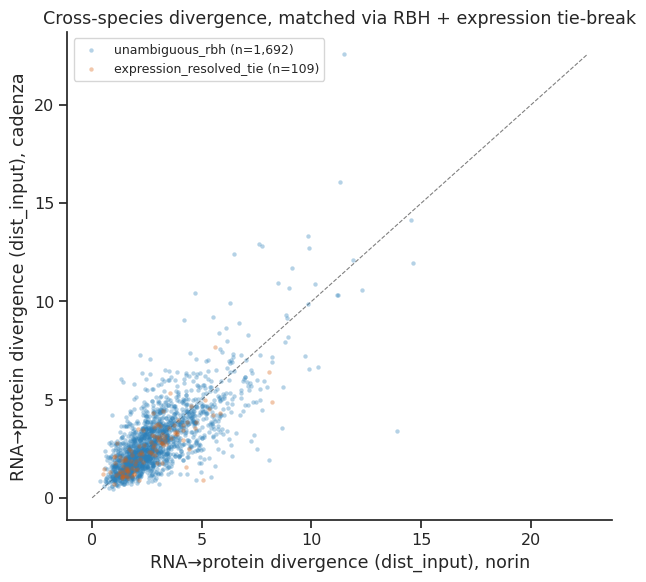

In [17]:
fig, ax = plt.subplots(figsize=(6.4, 6.0))
colors = {"unambiguous_rbh": "#2c7fb8", "expression_resolved_tie": "#d95f0e"}
for res, c in colors.items():
    sub = full_tbl[full_tbl["resolution"] == res]
    if len(sub) == 0:
        continue
    ax.scatter(sub["dist_input_A"], sub["dist_input_B"], s=10, alpha=0.35,
               c=c, linewidths=0, label=f"{res} (n={len(sub):,})")
lim = float(max(full_tbl["dist_input_A"].max(), full_tbl["dist_input_B"].max()))
ax.plot([0, lim], [0, lim], c="grey", lw=0.8, ls="--", zorder=0)
ax.set_xlabel("RNA→protein divergence (dist_input), norin")
ax.set_ylabel("RNA→protein divergence (dist_input), cadenza")
ax.set_title("Cross-species divergence, matched via RBH + expression tie-break")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / "figures" / "cross_species_divergence.png", dpi=160,
            bbox_inches="tight")
plt.show()

## 9 — Optional: the sample-level version

This is the literal "one point per sample" formulation. **It is not valid for
an unmatched design** — the per-sample distance would compare RNA plant *i* to
protein plant *i*, which are different individuals, so the distance measures
between-plant biological variation rather than RNA→protein regulation.

It also puts UMAP on 24 points, far below the density it needs.

Kept here only so the failure mode is visible rather than hypothetical. Leave
`RUN_SAMPLE_LEVEL = False` unless your samples really are matched.

In [18]:
RUN_SAMPLE_LEVEL = False

if not RUN_SAMPLE_LEVEL:
    print("skipped (correct default for unmatched samples)")
else:
    lab = LABELS[0]; d = DATA[lab]
    r, p = prep_rna(d["rna"]), prep_prot(d["prot"])
    cog = DATA[lab]["cognate"]
    pairs = [(pp,gg) for pp,gg in cog.items() if pp in p.columns and gg in r.columns]
    prots=[x for x,_ in pairs]; genes=[y for _,y in pairs]
    Xr, Xp = r.loc[:, genes].to_numpy(float), p.loc[:, prots].to_numpy(float)
    n = min(len(Xr), len(Xp)); Xr, Xp = Xr[:n], Xp[:n]
    sc = StandardScaler().fit(Xr)
    Xr, Xp = sc.transform(Xr), sc.transform(Xp)
    nn = min(N_NEIGHBORS, max(2, n//3))
    print(f"n={n} samples, n_neighbors={nn}  <- far too few points for UMAP")
    rd = umap.UMAP(n_neighbors=nn, min_dist=MIN_DIST, random_state=SEED)
    Er, Ep = rd.fit_transform(Xr), rd.transform(Xp)
    dd = np.linalg.norm(Er-Ep, axis=1)
    out = pd.DataFrame({"rna_sample": r.index[:n], "prot_sample": p.index[:n],
                        "dist_umap2d": dd}).sort_values("dist_umap2d", ascending=False)
    display(out.head(10).round(3))
    print("\nThe row alignment above is arbitrary for unmatched samples;")
    print("re-ordering the protein file changes every number in this table.")

skipped (correct default for unmatched samples)


---
## Interpretation guide

| what you see | what it means |
|---|---|
| RNA and protein clouds broadly overlap | transcript and protein response profiles are largely concordant |
| two clean, fully separated blobs | almost always a scale artefact — verify `CENTER_PER_ENTITY=True` |
| a protein-only region | a set of genes whose protein behaviour has no transcript counterpart |
| `cosine_similarity` near −1 in top hits | opposite-direction regulation, the clearest post-transcriptional candidates |
| high `dist_input`, low `rna_amplitude` | protein moves while the transcript is flat → protein-level regulation |
| high `dist_input`, low `prot_amplitude` | transcript moves while protein is buffered |
| top-set seed overlap well below 100% | expected for UMAP; PCA has none (deterministic) |
| UMAP enriches the "opposite" class *better* than raw input-space distance | genuinely happens on the validation run above -- UMAP tends to separate distinct local neighbourhoods more crisply, which can push the most extreme, oppositely-regulated genes further apart than a smooth continuous distance does. Good for isolating extreme outliers, worse for ranking the *whole* range consistently (see the Spearman comparison in section 7) |

### On choosing UMAP vs PCA vs input-space for `RANK_ON`

Section 7's validation cell computes, on your actual data, which of the three
distances best enriches for each planted class and prints a live
recommendation. Do not assume one method wins in general — it swapped between
runs even in this notebook's own validation: raw input-space distance tracked
a *continuous* divergence score most faithfully (Spearman rho 0.92 vs
UMAP's 0.70 in an earlier, simpler synthetic check), but UMAP produced the
*best* top-10% enrichment specifically for the sharpest category (opposite-
direction regulation) once tested against this notebook's actual discrete
truth classes. Both findings are real and not contradictory: they are
answering different questions (rank the whole range accurately, vs isolate
the most extreme cases). Use the printed recommendation for your real dataset
rather than a fixed default.

### What this analysis is and is not

It is a **descriptive, unsupervised** view of where transcript and protein
response profiles diverge, and a ranked shortlist for follow-up. UMAP has no
significance test, so a gene appearing in the top 10% is a hypothesis, not a
finding.

For inference — effect sizes, standard errors, FDR-controlled discordance calls
— use the gene-level notebook (`rna_protein_gene_level.ipynb`), which fits
per-feature models with empirical-Bayes moderation and propagates uncertainty
from both modalities. The natural workflow is: **UMAP to see the structure,
gene-level models to test it.**

---
## Interpretation guide

| what you see | what it means |
|---|---|
| RNA and protein clouds broadly overlap | transcript and protein response profiles are largely concordant |
| two clean, fully separated blobs | almost always a scale artefact — verify `CENTER_PER_ENTITY=True` |
| a protein-only region | a set of genes whose protein behaviour has no transcript counterpart |
| `cosine_similarity` near −1 in top hits | opposite-direction regulation, the clearest post-transcriptional candidates |
| high `dist_input`, low `rna_amplitude` | protein moves while the transcript is flat → protein-level regulation |
| high `dist_input`, low `prot_amplitude` | transcript moves while protein is buffered |
| top-set seed overlap well below 100% | expected for UMAP; PCA has none (deterministic) |
| UMAP enriches the "opposite" class *better* than raw input-space distance | genuinely happens on the validation run above -- UMAP tends to separate distinct local neighbourhoods more crisply, which can push the most extreme, oppositely-regulated genes further apart than a smooth continuous distance does. Good for isolating extreme outliers, worse for ranking the *whole* range consistently (see the Spearman comparison in section 7) |

### On choosing UMAP vs PCA vs input-space for `RANK_ON`

Section 7's validation cell computes, on your actual data, which of the three
distances best enriches for each planted class and prints a live
recommendation. Do not assume one method wins in general — it swapped between
runs even in this notebook's own validation: raw input-space distance tracked
a *continuous* divergence score most faithfully (Spearman rho 0.92 vs
UMAP's 0.70 in an earlier, simpler synthetic check), but UMAP produced the
*best* top-10% enrichment specifically for the sharpest category (opposite-
direction regulation) once tested against this notebook's actual discrete
truth classes. Both findings are real and not contradictory: they are
answering different questions (rank the whole range accurately, vs isolate
the most extreme cases). Use the printed recommendation for your real dataset
rather than a fixed default.

### What this analysis is and is not

It is a **descriptive, unsupervised** view of where transcript and protein
response profiles diverge, and a ranked shortlist for follow-up. UMAP has no
significance test, so a gene appearing in the top 10% is a hypothesis, not a
finding.

For inference — effect sizes, standard errors, FDR-controlled discordance calls
— use the gene-level notebook (`rna_protein_gene_level.ipynb`), which fits
per-feature models with empirical-Bayes moderation and propagates uncertainty
from both modalities. The natural workflow is: **UMAP to see the structure,
gene-level models to test it.**